### **Imports**

In [223]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

### **Load data**

#### Iris

In [224]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [225]:
# Convert to DataFrame for easier inspection
df = pd.DataFrame(X, columns=feature_names)
df['species'] = pd.Categorical.from_codes(y, target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### **Task 1**

#### Decision Tree using Iris dataset

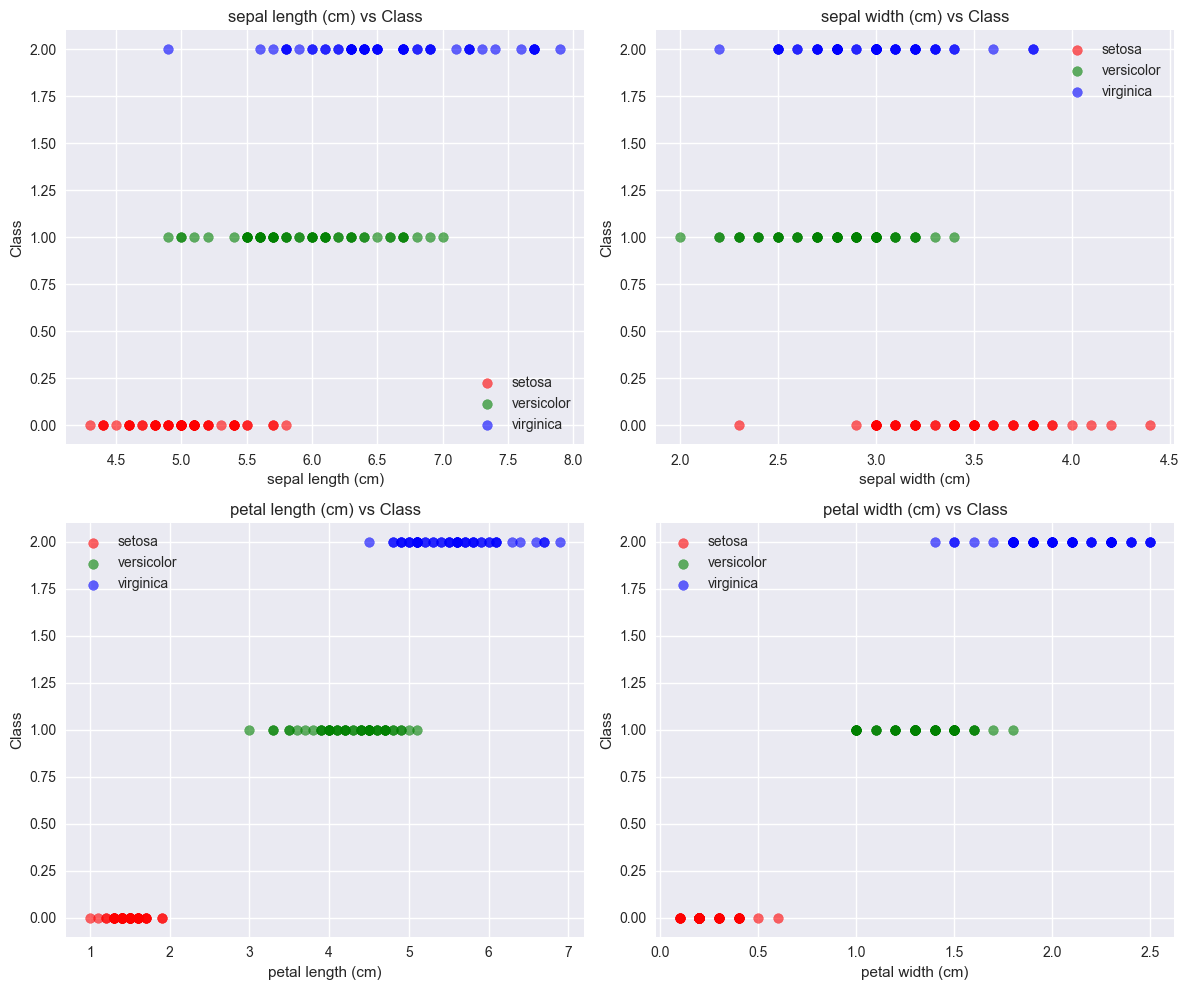

In [226]:
# Visualize the dataset: pairplot of features
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()
colors = ['red', 'green', 'blue']
for i in range(4):
    for j in range(3):
        axs[i].scatter(X[y == j, i], y[y == j], label=target_names[j], alpha=0.6, color=colors[j])
    axs[i].set_xlabel(feature_names[i])
    axs[i].set_ylabel("Class")
    axs[i].legend()
    axs[i].set_title(f"{feature_names[i]} vs Class")
plt.tight_layout()

In [227]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### a) Using gini criterion

In [228]:
# Build Decision Tree classifier
clf = DecisionTreeClassifier(criterion="gini", random_state=42)
clf.fit(X_train, y_train)
# Predict and evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.2f}")

Decision Tree Accuracy: 1.00


Text(0.5, 1.0, 'Decision tree (criterion: gini)')

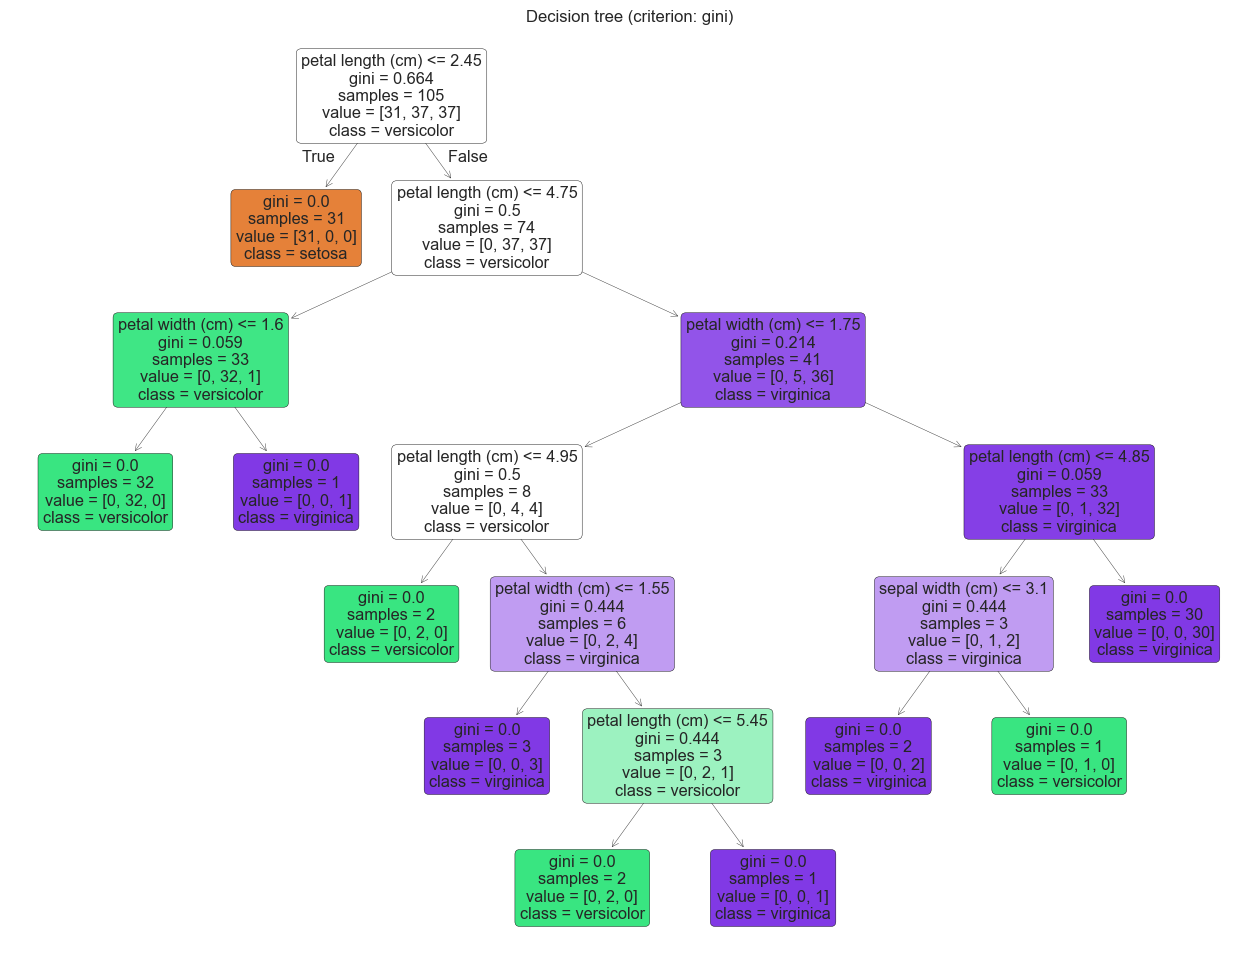

In [229]:
# Visualize the decision tree structure
plt.figure(figsize=(16, 12))
plot_tree(clf, feature_names=feature_names, class_names=target_names, filled=True, rounded=True)
plt.title("Decision tree (criterion: gini)")

#### Interpretation of classification criteria
#### First classification: based on petal length (cm). If petal length ≤ 2.45 cm → setosa species (very easy to distinguish). Subsequent divisions: distinguish between versicolor and virginica. Typical rules: If petal length ≤ 4.75 cm → versicolor. If petal width > 1.75 cm → virginica.

#### Interpretation: the tree learns simple thresholds on flower characteristics that maximize class purity at each node. This makes it easy to read the classification rules in “if–else” form.

#### b) Using entropy criterion

In [230]:
# Build Decision Tree classifier
clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf_entropy.fit(X_train, y_train)
# Predict and evaluate
y_pred = clf_entropy.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.2f}")

Decision Tree Accuracy: 0.98


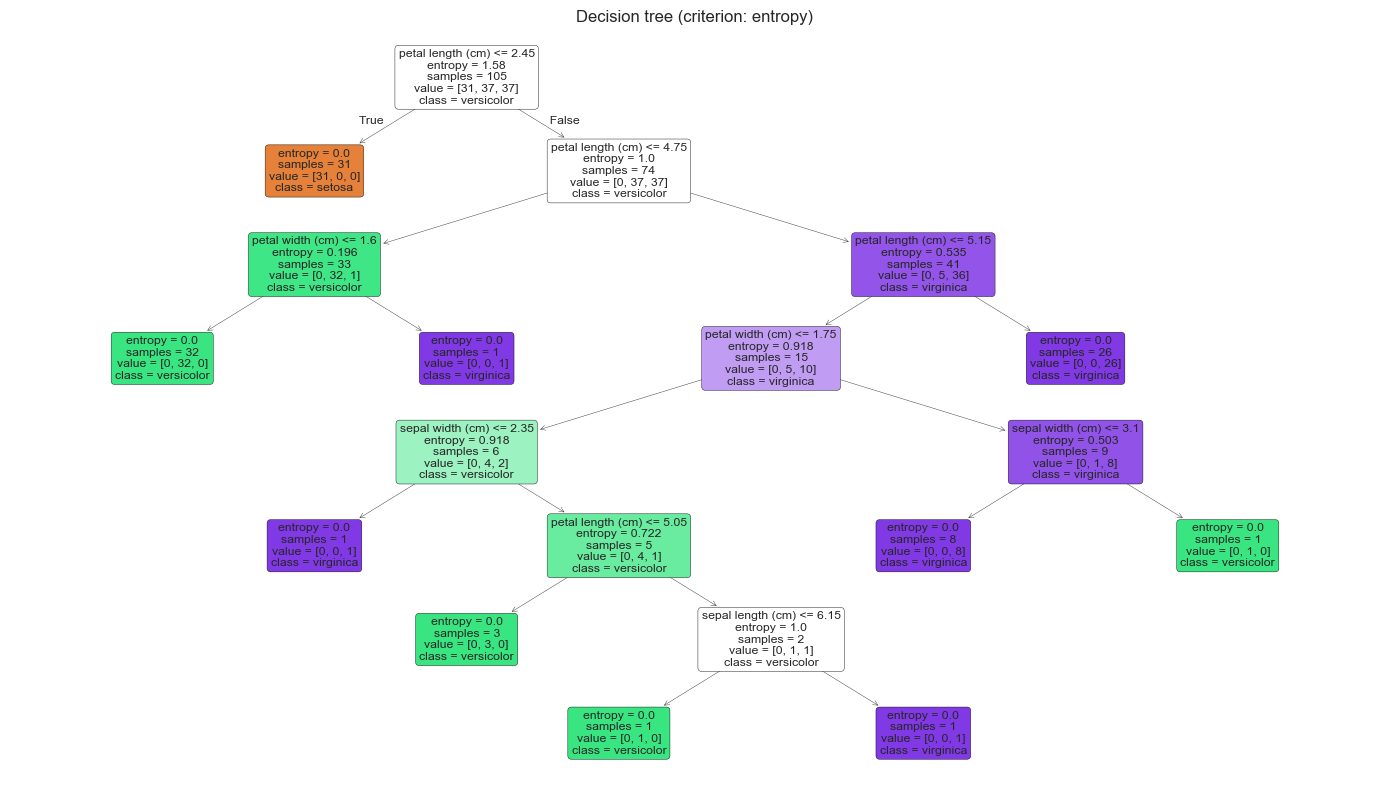

In [231]:
plt.figure(figsize=(14, 8))
plot_tree(
    clf_entropy,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision tree (criterion: entropy)")
plt.tight_layout()
plt.show()

#### Interpretation of differences
#### Gini: Measures the probability of misclassification if we randomly assign a label according to the distribution of classes in a node, faster in calculations, often chosen as the default.

#### Entropy (Information Gain): Based on Shannon's information theory, measures the “uncertainty” of a node and selects splits that maximize entropy reduction, often produces trees very similar to Gini, but sometimes selects different features for equivalent splits.

### **Task 2**

In [232]:
# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree with default parameters (no depth limit)
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(X_train, y_train)

# Train Decision Tree with max_depth=3
tree_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_limited.fit(X_train, y_train)

# Predict and evaluate both models
y_pred_default_train = tree_default.predict(X_train)
y_pred_default_test = tree_default.predict(X_test)

y_pred_limited_train = tree_limited.predict(X_train)
y_pred_limited_test = tree_limited.predict(X_test)

# Compute accuracy scores
acc_default_train = accuracy_score(y_train, y_pred_default_train)
acc_default_test = accuracy_score(y_test, y_pred_default_test)

acc_limited_train = accuracy_score(y_train, y_pred_limited_train)
acc_limited_test = accuracy_score(y_test, y_pred_limited_test)

# Print results
print("Decision Tree (no depth limit):")
print(f"  Training Accuracy: {acc_default_train:.3f}")
print(f"  Testing Accuracy:  {acc_default_test:.3f}")

print("\nDecision Tree (max_depth=3):")
print(f"  Training Accuracy: {acc_limited_train:.3f}")
print(f"  Testing Accuracy:  {acc_limited_test:.3f}")

Decision Tree (no depth limit):
  Training Accuracy: 1.000
  Testing Accuracy:  1.000

Decision Tree (max_depth=3):
  Training Accuracy: 0.958
  Testing Accuracy:  1.000


Text(0.5, 1.0, 'Decision Tree (max_depth=3)')

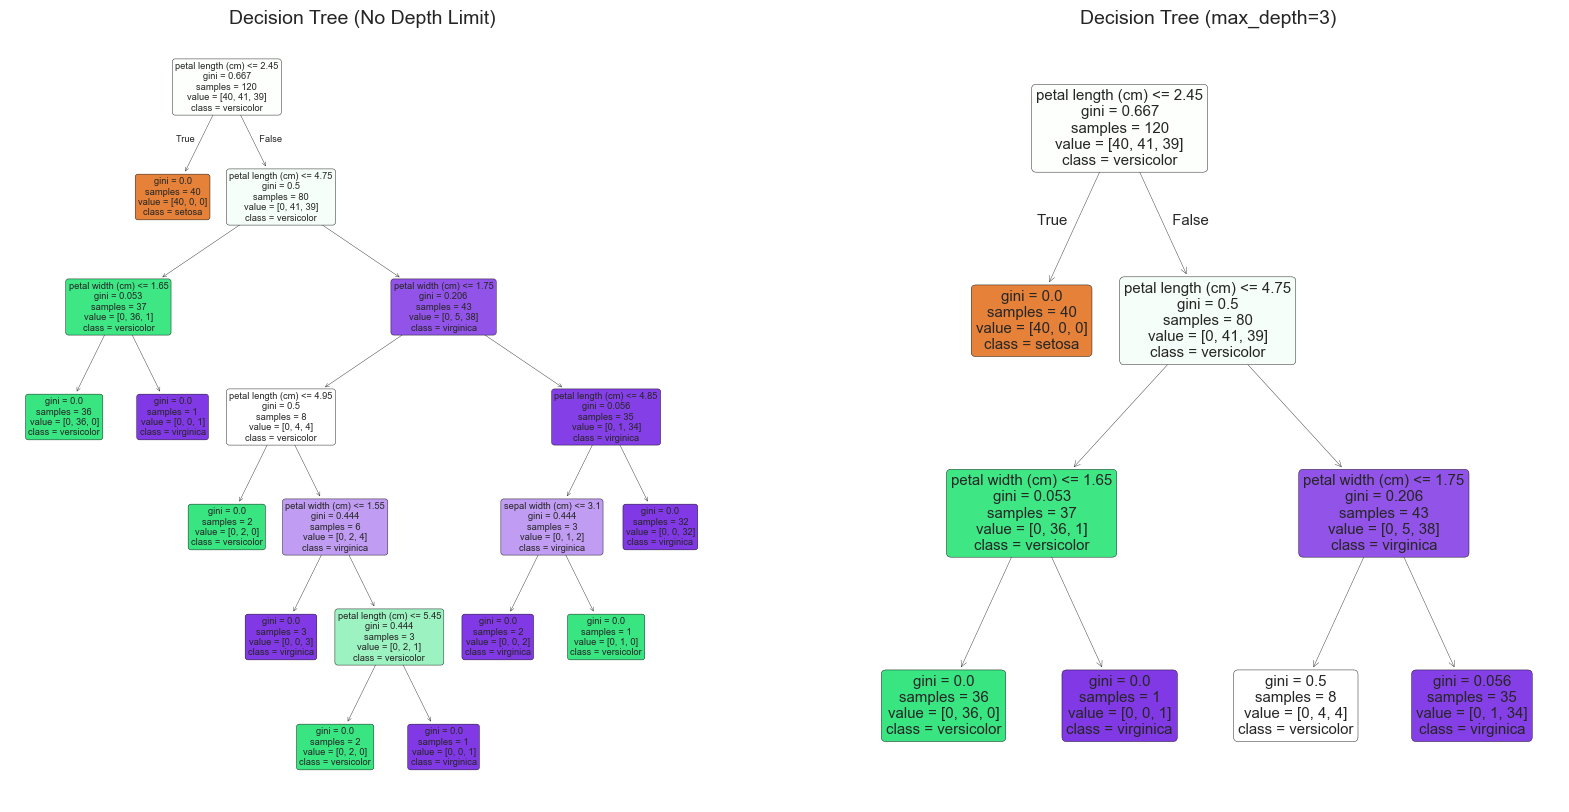

In [233]:
# Create subplots
plt.figure(figsize=(20, 10))

# Plot default tree
plt.subplot(1, 2, 1)
plot_tree(tree_default, filled=True, rounded=True, feature_names=feature_names, class_names=target_names)
plt.title("Decision Tree (No Depth Limit)", fontsize=14)

# Plot limited depth tree
plt.subplot(1, 2, 2)
plot_tree(tree_limited, filled=True, rounded=True, feature_names=feature_names, class_names=target_names)
plt.title("Decision Tree (max_depth=3)", fontsize=14)

### **Task 3**

In [234]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Single tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

# Random forest
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
y_pred_forest = forest.predict(X_test)

# Comparison
acc_tree_train = accuracy_score(y_train, tree.predict(X_train))
acc_tree_test = accuracy_score(y_test, y_pred_tree)

acc_forest_train = accuracy_score(y_train, forest.predict(X_train))
acc_forest_test = accuracy_score(y_test, y_pred_forest)

print("Single tree:")
print(f"  Training accuracy: {acc_tree_train:.3f}")
print(f"  Test accuracy:    {acc_tree_test:.3f}")

print("\nRandom forest:")
print(f"  Training accuracy: {acc_forest_train:.3f}")
print(f"  Test accuracy:    {acc_forest_test:.3f}")

Single tree:
  Training accuracy: 1.000
  Test accuracy:    0.933

Random forest:
  Training accuracy: 1.000
  Test accuracy:    0.889


#### For a small dataset like Iris, a single tree was sufficient. However, in a more complex environment, Random forest may provide more accurate results.

### **Task 4**

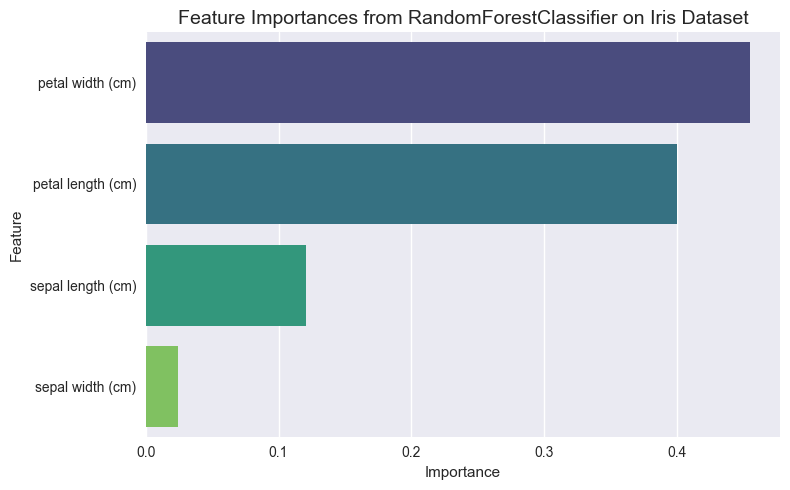

In [235]:
# Extract feature importances
importances = forest.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue = 'Feature', legend=False)
plt.title('Feature Importances from RandomForestClassifier on Iris Dataset', fontsize=14)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

### **Task 5**

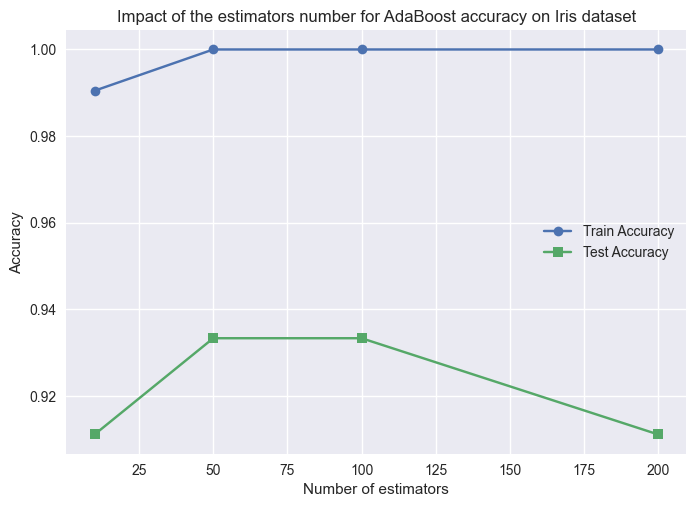

In [236]:
# Testing different values of n_estimators
estimators_range = [10, 50, 100, 200]
train_acc = []
test_acc = []

for n in estimators_range:
    model = AdaBoostClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

# Visualization
plt.plot(estimators_range, train_acc, marker='o', label='Train Accuracy')
plt.plot(estimators_range, test_acc, marker='s', label='Test Accuracy')
plt.xlabel("Number of estimators")
plt.ylabel("Accuracy")
plt.title("Impact of the estimators number for AdaBoost accuracy on Iris dataset")
plt.legend()
plt.show()

#### AdaBoost works iteratively: successive classifiers focus on examples that were previously misclassified. More estimators mean greater model power, but also a higher risk of overfitting. The optimal number depends on the data. In our case, 50–100 estimators is sufficient.

### **Task 6**

In [237]:
# Train a Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate both models
gb_train_acc = accuracy_score(y_train, gb_model.predict(X_train))
gb_test_acc = accuracy_score(y_test, gb_model.predict(X_test))

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_model.predict(X_test))

print("\nRandom Forest:")
print(f"  Training accuracy: {rf_train_acc:.3f}")
print(f"  Testing accuracy:  {rf_test_acc:.3f}")

print("Gradient Boosting:")
print(f"  Training accuracy: {gb_train_acc:.3f}")
print(f"  Testing accuracy:  {gb_test_acc:.3f}")


Random Forest:
  Training accuracy: 1.000
  Testing accuracy:  0.889
Gradient Boosting:
  Training accuracy: 1.000
  Testing accuracy:  0.933


#### Random Forest:<br> Builds many independent decision trees in parallel.<br> Each tree is trained on a random subset of data and features.<br> Final prediction is made by majority vote (classification) or averaging (regression).<br>Goal: reduce variance and avoid overfitting by combining diverse trees.

#### Gradient Boosting:<br>Builds trees sequentially, each new tree correcting the errors of the previous ones.<br>Uses gradient descent to minimize a loss function.<br>Trees are typically shallow (weak learners), but together they form a strong model.<br>Goal: reduce bias by iteratively improving predictions.

### **Task 7**

In [238]:
# Train XGBoost
start = time.time()
xgb_model = XGBClassifier(n_estimators=100, eval_metric="mlogloss")
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))

# Train a single tree
start = time.time()
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_time = time.time() - start
tree_acc = accuracy_score(y_test, tree_model.predict(X_test))

# Train Random forest
start = time.time()
forest_model = RandomForestClassifier(n_estimators=100)
forest_model.fit(X_train, y_train)
forest_time = time.time() - start
forest_acc = accuracy_score(y_test, forest_model.predict(X_test))

# Train AdaBoost
start = time.time()
adaboost_model = AdaBoostClassifier(n_estimators=100)
adaboost_model.fit(X_train, y_train)
adaboost_time = time.time() - start
adaboost_acc = accuracy_score(y_test, adaboost_model.predict(X_test))

# Train GradientBoost
start = time.time()
gradient_model = GradientBoostingClassifier(n_estimators=100)
gradient_model.fit(X_train, y_train)
gradient_time = time.time() - start
gradient_acc = accuracy_score(y_test, gradient_model.predict(X_test))

print(f"XGBoost: Accuracy={xgb_acc:.3f}, Training time={xgb_time:.3f}s")
print(f"Decision tree: Accuracy={tree_acc:.3f}, Training time={tree_time:.3f}s")
print(f"RandomForest: Accuracy={forest_acc:.3f}, Training time={forest_time:.3f}s")
print(f"AdaBoost: Accuracy={adaboost_acc:.3f}, Training time={adaboost_time:.3f}s")
print(f"GradientBoosting: Accuracy={gradient_acc:.3f}, Training time={gradient_time:.3f}s")

XGBoost: Accuracy=0.933, Training time=0.186s
Decision tree: Accuracy=0.933, Training time=0.001s
RandomForest: Accuracy=0.911, Training time=0.132s
AdaBoost: Accuracy=0.933, Training time=0.206s
GradientBoosting: Accuracy=0.933, Training time=0.242s


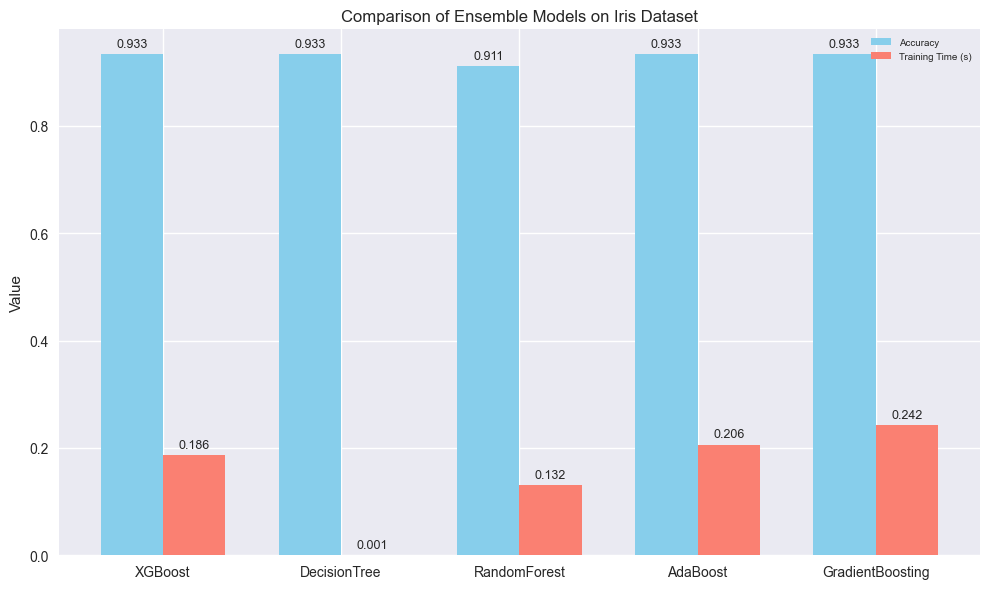

In [239]:
# Collect results from your training
models = ["XGBoost", "DecisionTree", "RandomForest", "AdaBoost", "GradientBoosting"]
accuracy = [xgb_acc, tree_acc, forest_acc, adaboost_acc, gradient_acc]
training_time = [xgb_time, tree_time, forest_time, adaboost_time, gradient_time]

x = np.arange(len(models))  # positions for models
width = 0.35                # bar width

plt.figure(figsize=(10, 6))

# Accuracy bars
bars1 = plt.bar(x - width/2, accuracy, width, label="Accuracy", color="skyblue")

# Training time bars
bars2 = plt.bar(x + width/2, training_time, width, label="Training Time (s)", color="salmon")

# Labels and title
plt.ylabel("Value")
plt.title("Comparison of Ensemble Models on Iris Dataset")
plt.xticks(x, models)
plt.legend(loc="upper right", fontsize = 7)

# Annotate bars with values
for bar in bars1:
    height = bar.get_height()
    plt.annotate(f"{height:.3f}",
                 xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha="center", va="bottom", fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.annotate(f"{height:.3f}",
                 xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

#### For small datasets like Iris, differences are minor. For large, complex datasets, XGBoost’s optimizations make a big difference.

#### Reasons behind XGBoost popularity: <br>Performance: XGBoost consistently delivers high accuracy on structured/tabular data;<br>Speed: Written in C++, supports parallelization and efficient memory usage;<br>Regularization: Includes L1/L2 regularization to reduce overfitting, unlike vanilla gradient boosting;<br>Flexibility: Handles missing values, supports custom loss functions, and scales to millions of rows.